# Strategy comparison: which phasing shape/intensity wins?

**Question:** which phasing strategy wins across variance, bias and
identifiability, and what does it cost? `DiscoveryReport` already sweeps a
lever grid and scores every candidate on these exact axes (see
`_pick_winner` in `_discovery_report.py`), so this notebook drives that
class directly rather than reimplementing the measurement by hand.

Uses `DiscoveryReport`'s own default lever grid (`levers=` left unset):
unphased, then +/-20% at each of uniform, edge-balanced and seesaw, then
+/-20% Redistribute, +/-20% MonthStep and the single-week Blackout
(dark=1). 7 candidates on the same scenario as notebook 01. Reading
`report.levers_` here rather than hand-copying a list keeps this notebook
in sync with `_default_levers`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from how_wrong_is_your_mmm import DiscoveryReport, simulate_demand, simulate_spend
from how_wrong_is_your_mmm._dgp import channel_contributions
from how_wrong_is_your_mmm._discovery_report import _safe_improvement

plt.rcParams["figure.figsize"] = (9, 3.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Same four channels/economics and scenario as notebook 01.
CHANNELS = ["tv", "meta", "search_generic", "tiktok"]
TRUE_MARGINAL_RETURNS = {"tv": 0.5, "meta": 1.0, "search_generic": 1.5, "tiktok": 1.2}
TRUE_SATURATION = {"tv": 0.60, "meta": 0.75, "search_generic": 0.90, "tiktok": 0.70}
TRUE_ADSTOCK = {"tv": 0.50, "meta": 0.30, "search_generic": 0.10, "tiktok": 0.20}

# Same recipe as tools/generate_example_report.py (docs/example-report.html):
# one 156-week trend demand series drives the spend, split into 2 years of
# history from 2025-01-06 (spend seed 12) and a 1-year plan from 2027-01-04
# (spend seed 13), correlation 0.7. The report then builds its own demand
# series from this spend at the package defaults (demand_spend_corr 0.65,
# trend), the same path a real client's spend takes.
N_HISTORY, N_PLAN = 104, 52
DEMAND = simulate_demand(N_HISTORY + N_PLAN, process="trend", seed=6)


def scenario_spend(correlation=0.7):
    history = simulate_spend(
        n_obs=N_HISTORY,
        correlation=correlation,
        channels=CHANNELS,
        seed=12,
        start_date="2025-01-06",
        demand=DEMAND[:N_HISTORY],
    )
    plan = simulate_spend(
        n_obs=N_PLAN,
        correlation=correlation,
        channels=CHANNELS,
        seed=13,
        start_date="2027-01-04",
        demand=DEMAND[N_HISTORY:],
    )
    return history, plan


history_df, plan_df = scenario_spend()

report = DiscoveryReport(
    history_df=history_df,
    plan_df=plan_df,
    true_marginal_returns=TRUE_MARGINAL_RETURNS,
    saturation=TRUE_SATURATION,
    adstock=TRUE_ADSTOCK,
    # levers left unset -- this is _default_levers(CHANNELS), read back
    # below rather than hand-copied, so this notebook tracks the source.
)
# Reduced sim counts for notebook speed, same convention as notebook 01 --
# bump these for numbers going into the live report/overview.html for real.
report.fit(n_sims=20, n_phasing_seeds=3, id_n_sims=8)
LEVER_ORDER = [label for label, *_ in report.levers_]
print(f"winner: {report.winner_}")
print(f"{len(LEVER_ORDER)} candidates: {LEVER_ORDER}")

winner: +/-20% (redistribute + edge)
7 candidates: ['unphased', '+/-20% (uniform)', '+/-20% (edge, balanced)', '+/-20% (seesaw)', '+/-20% (redistribute + edge)', '+/-20% (month step)', 'Blackout (dark=1)']


## The comparison table

Three reliability columns straight from `report.summary()` -- the exact
report-wide (mean-across-channel) criterion `_pick_winner` itself scores
levers on, so this is provably the same evidence a live report's winner is
chosen from, not a fresh computation. Cost is not part of `summary()`, so
it is added the same way `_discovery_report.py`'s own `_render_html`
computes it for the Appendix: `channel_contributions` on history + each
lever's own schedule, compared against the unphased truth.

In [2]:
combined_unphased = pd.concat([report.history_df, report.plan_df])
true_contributions = channel_contributions(
    combined_unphased,
    report.true_marginal_returns,
    report.saturation,
    report.adstock,
    report.reference_spend_,
)
true_revenue = {
    ch: float(true_contributions[ch].iloc[-len(report.plan_df) :].sum())
    for ch in CHANNELS
}

cost_pct = {}
for label in LEVER_ORDER:
    lever_contributions = channel_contributions(
        pd.concat([report.history_df, report.schedules_[label]]),
        report.true_marginal_returns,
        report.saturation,
        report.adstock,
        report.reference_spend_,
    )
    lever_revenue = {
        ch: float(lever_contributions[ch].iloc[-len(report.plan_df) :].sum())
        for ch in CHANNELS
    }
    cost_pct[label] = 100 * float(
        np.mean(
            [_safe_improvement(true_revenue[ch], lever_revenue[ch]) for ch in CHANNELS]
        )
    )

table = report.summary().set_index("lever").loc[LEVER_ORDER]
table["cost_pct"] = pd.Series(cost_pct)
table = table.rename(
    columns={
        "mean_variance_cv": "variance: CV",
        "mean_abs_bias_pct": "bias: |%|",
        "identifiability_valley_pct": "identifiability: valley %",
        "cost_pct": "cost: revenue given up %",
    }
)[
    [
        "variance: CV",
        "bias: |%|",
        "identifiability: valley %",
        "cost: revenue given up %",
        "is_winner",
    ]
]
pd.set_option("display.width", 200)
print(table.round(3).to_string())

                              variance: CV  bias: |%|  identifiability: valley %  cost: revenue given up %  is_winner
lever                                                                                                                
unphased                             0.256     29.389                     41.080                     0.000      False
+/-20% (uniform)                     0.230     29.584                     39.980                     0.063      False
+/-20% (edge, balanced)              0.196     29.188                     37.838                     0.251      False
+/-20% (seesaw)                      0.206     30.744                     36.698                     0.168      False
+/-20% (redistribute + edge)         0.088     17.125                     11.852                     1.943       True
+/-20% (month step)                  0.163     27.932                     36.087                     0.236      False
Blackout (dark=1)                    0.089     21.125   

## Impact vs unphased, and a picture

`variance`/`bias`/`identifiability` below are `_pick_winner`'s own
improvement-over-unphased fractions (lower raw score is better for all
three), so "biggest bar" means "most improved," matching the winner
selection exactly. Cost has no unphased row -- there is nothing to compare
a zero-deviation plan's revenue against.

                              variance % improved  bias % improved  identifiability % improved  cost: revenue given up %
lever                                                                                                                   
+/-20% (uniform)                             10.4             -0.7                         2.7                       0.1
+/-20% (edge, balanced)                      23.6              0.7                         7.9                       0.3
+/-20% (seesaw)                              19.7             -4.6                        10.7                       0.2
+/-20% (redistribute + edge)                 65.6             41.7                        71.1                       1.9
+/-20% (month step)                          36.4              5.0                        12.2                       0.2
Blackout (dark=1)                            65.4             28.1                        63.2                       1.5


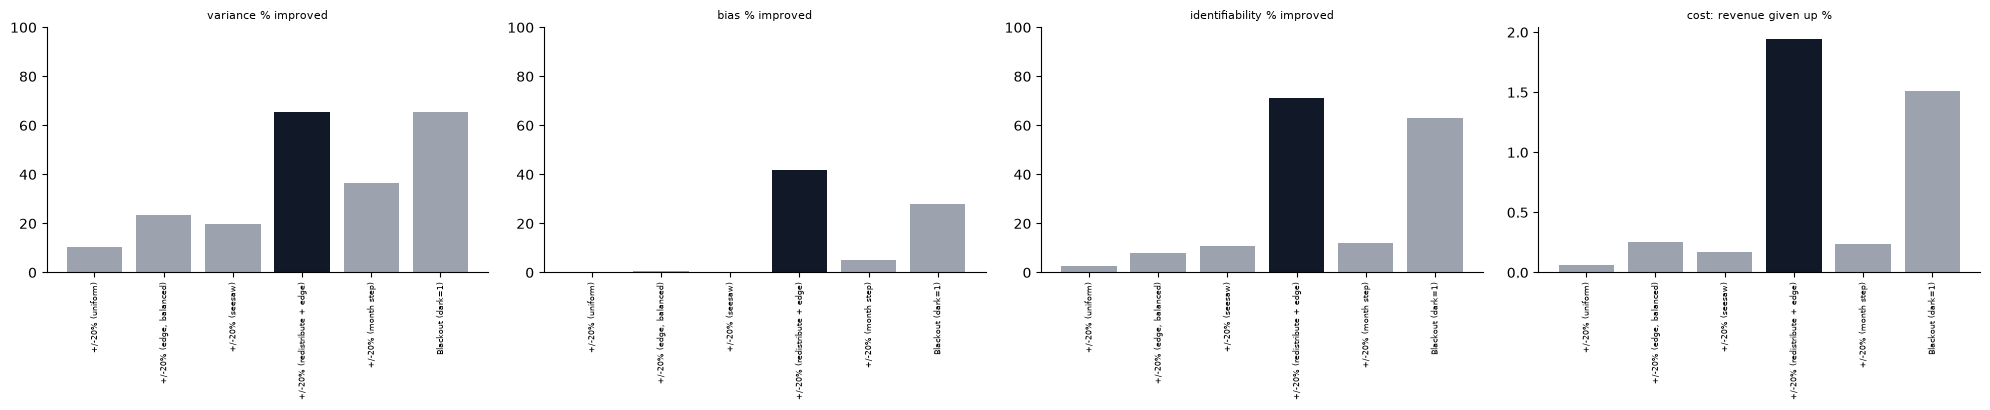

In [3]:
baseline_scores = report.results_["unphased"]["scores"]
impact_rows = []
for label in LEVER_ORDER[1:]:
    scores = report.results_[label]["scores"]
    impact_rows.append(
        {
            "lever": label,
            "variance % improved": 100
            * _safe_improvement(baseline_scores["variance"], scores["variance"]),
            "bias % improved": 100
            * _safe_improvement(baseline_scores["bias"], scores["bias"]),
            "identifiability % improved": 100
            * _safe_improvement(
                baseline_scores["identifiability"], scores["identifiability"]
            ),
            "cost: revenue given up %": cost_pct[label],
        }
    )
impact = pd.DataFrame(impact_rows).set_index("lever")
print(impact.round(1).to_string())

# Generic colouring for an arbitrary-length lever grid (16 candidates,
# vs the old hand-picked 5 a fixed label->colour dict could name): the
# winner in the report's own "recommended" navy, everything else a
# neutral grey, so the chart scales with _default_levers without needing
# a colour entry added by hand every time a candidate is added.
WINNER_COLOR = "#111827"
OTHER_COLOR = "#9ca3af"
bar_colors = [
    WINNER_COLOR if lv == report.winner_ else OTHER_COLOR for lv in impact.index
]

panels = ["variance % improved", "bias % improved", "identifiability % improved"]
fig, axes = plt.subplots(1, 4, figsize=(20, 4.2))
for ax, col in zip(axes[:3], panels):
    vals = impact[col]
    ax.bar(vals.index, vals, color=bar_colors)
    ax.set_title(col, fontsize=8)
    ax.tick_params(axis="x", rotation=90, labelsize=6)
    ax.set_ylim(0, 100)
ax = axes[3]
vals = impact["cost: revenue given up %"]
ax.bar(vals.index, vals, color=bar_colors)
ax.set_title("cost: revenue given up %", fontsize=8)
ax.tick_params(axis="x", rotation=90, labelsize=6)
plt.tight_layout()
plt.show()

## Bringing it together

Scenario: 2 years of trend-driven history plus a 1-year plan, demand
linked to spend at the default 0.65 correlation. Reduced sim counts
(`n_sims=20`, `n_phasing_seeds=3`, so 3 demand draws for bias), so treat
single-digit gaps as noise.

**`+/-20% (redistribute + edge)` wins on all three axes.** Variance
improves 65.6%, bias 41.7% and identifiability 71.1% over unphased. It
costs 1.9% of plan-period revenue under the assumed saturation curves.

**`Blackout (dark=1)` is the close second.** 65.4% / 28.1% / 63.2% at
1.5% cost. It ties on variance and loses on bias and identifiability.

**The within-month shapes barely touch bias.** `edge, balanced` improves
variance 23.6% but bias only 0.7%. `uniform` and `seesaw` make bias
slightly worse (-0.7% and -4.6%). They only reshuffle spend inside each
month, which leaves the month-to-month link between spend and a trending
demand series in place.

**`month step` sits in between.** 36.4% / 5.0% / 12.2% at 0.2% cost. It
moves budget between months but in fixed steps, without Redistribute's
blackout months.